In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load clean data
df = pd.read_csv('../outputs/secom_clean.csv')
labels = pd.read_csv('../outputs/secom_labels_clean.csv')

print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")

Loaded: 1567 rows x 562 columns


In [2]:
# Z-score based anomaly detector
# For each production run, count how many sensors read abnormally
# A sensor reading is "anomalous" if it is more than 3 standard deviations from the mean

def detect_anomalies(data, threshold=3.0):
    mean = data.mean()
    std = data.std()
    z_scores = (data - mean) / std
    anomalous_sensors = (z_scores.abs() > threshold)
    return anomalous_sensors.sum(axis=1)

# Apply to full dataset
anomaly_scores = detect_anomalies(df)

print("Anomaly detection complete.")
print(f"Average anomalous sensors per run: {anomaly_scores.mean():.1f}")
print(f"Max anomalous sensors in one run: {anomaly_scores.max()}")
print(f"Runs with 0 anomalous sensors: {(anomaly_scores == 0).sum()}")

# Define alert threshold — runs with unusually high anomaly scores
alert_threshold = anomaly_scores.mean() + 2 * anomaly_scores.std()
high_alert_runs = (anomaly_scores > alert_threshold).sum()
print(f"Alert threshold: {alert_threshold:.1f} anomalous sensors")
print(f"Runs exceeding alert threshold: {high_alert_runs} ({high_alert_runs/len(df)*100:.1f}%)")

Anomaly detection complete.
Average anomalous sensors per run: 4.0
Max anomalous sensors in one run: 52
Runs with 0 anomalous sensors: 288
Alert threshold: 13.9 anomalous sensors
Runs exceeding alert threshold: 64 (4.1%)


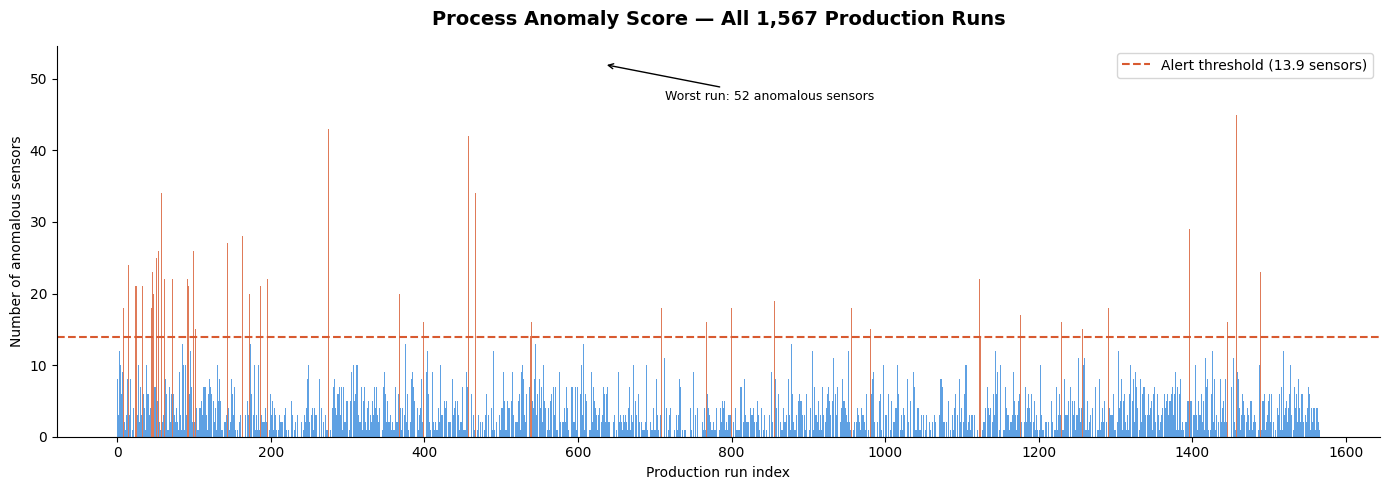

Chart saved.


In [3]:
# Chart: Anomaly scores across all production runs
fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#D85A30' if score > alert_threshold else '#378ADD' 
          for score in anomaly_scores]

ax.bar(range(len(anomaly_scores)), anomaly_scores.values, 
       color=colors, width=1.0, edgecolor='none', alpha=0.8)

ax.axhline(y=alert_threshold, color='#D85A30', linestyle='--', 
           linewidth=1.5, label='Alert threshold (' + str(round(alert_threshold, 1)) + ' sensors)')

ax.set_title('Process Anomaly Score — All 1,567 Production Runs', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Production run index')
ax.set_ylabel('Number of anomalous sensors')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add annotation for worst run
worst_run = anomaly_scores.idxmax()
ax.annotate('Worst run: ' + str(anomaly_scores.max()) + ' anomalous sensors',
            xy=(worst_run, anomaly_scores.max()),
            xytext=(worst_run + 80, anomaly_scores.max() - 5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/04_anomaly_scores.png', dpi=150)
plt.show()
print("Chart saved.")

In [4]:
# Key question: do high anomaly scores predict failures?
df_results = pd.DataFrame({
    'anomaly_score': anomaly_scores,
    'outcome': labels['outcome'].values
})

pass_scores = df_results[df_results['outcome'] == -1]['anomaly_score']
fail_scores = df_results[df_results['outcome'] == 1]['anomaly_score']

print("Anomaly scores by outcome:")
print(f"  Pass runs — mean score: {pass_scores.mean():.1f}, max: {pass_scores.max()}")
print(f"  Fail runs — mean score: {fail_scores.mean():.1f}, max: {fail_scores.max()}")
print()

above_threshold_pass = (pass_scores > alert_threshold).sum()
above_threshold_fail = (fail_scores > alert_threshold).sum()
print(f"Runs above alert threshold:")
print(f"  Pass runs: {above_threshold_pass} ({above_threshold_pass/len(pass_scores)*100:.1f}%)")
print(f"  Fail runs: {above_threshold_fail} ({above_threshold_fail/len(fail_scores)*100:.1f}%)")

Anomaly scores by outcome:
  Pass runs — mean score: 3.8, max: 45
  Fail runs — mean score: 5.7, max: 52

Runs above alert threshold:
  Pass runs: 54 (3.7%)
  Fail runs: 10 (9.6%)
